<div style=" border-bottom: 8px solid #e3f56c; overflow: hidden; border-radius: 10px; height: 95%; width: 100%; display: flex;">
  <div style="height: 100%; width: 100%; background-color: #3800BB; float: left; text-align: center; display: flex; justify-content: left; align-items: center; font-size: 40px; ">
    <b><span style="color: #FFFFFF; padding: 20px 20px;">Santander Customer Satisfaction: Baseline Model</span></b>
  </div>
</div>

<div class="alert" style="background-color: #FFFFFF; border-left: 8px solid #B12111; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **This notebook focuses on developing the initial baseline model for the [Santander Customer Satisfaction competition](https://www.kaggle.com/c/santander-customer-satisfaction/overview).**

FULL PIPELINE FOR BINARY CLASSIFICATION (IMBALANCED DATA)  
**Model**: Decision Tree  
**Imbalance**: ~96% of class 0 and 4% of class 1  

**The main steps include:**

<div class="alert alert-danger">

**Workflow Overview**
</div>


================================================================



- Demonstrate a complete, professional workflow + implementation of decision tree.
- Include preprocessing, handling of imbalance, model tuning, and diagnostics.
- Keep modular structure so each block can be run separately.

1. **Import Libraries and Setup**: Load essential Python libraries for data manipulation, preprocessing, model training, and evaluation.  
2. **Load Data**: Import datasets into memory for analysis and modeling.  
3. **Split into Train/Test Sets**: Divide the data into training and test subsets, typically using an 80/20 ratio for unbiased evaluation.  
4. **Define Preprocessing for Numeric and Categorical Features**: Specify transformations to handle missing values, scale numeric features, and encode categorical variables.  
5. **Define the Model (Decision Tree)**: Initialize a Decision Tree classifier - a simple, interpretable baseline model for tabular data.  
6. **Build Full Pipeline with Preprocessing + Model**: Combine preprocessing steps and the model into a single pipeline for clean and reproducible workflows.  
7. **Define Hyperparameter Grid for Tuning**: Set up a parameter grid (e.g., `max_depth`, `min_samples_split`, `min_samples_leaf`) to optimize model performance.  
8. **Train the Model**: Fit the pipeline on the training data, optionally using cross-validation for robust performance estimation.  
9. **Save Best Model to Disk**: Persist the trained model for later inference or deployment.  
10. **Evaluate on Test (Validation) Data**: Assess model performance using metrics like ROC AUC, precision, recall, and accuracy.  
11. **Visual Diagnostics (Optional)**: Generate standard classification plots to interpret and validate model behavior:  
    - **ROC Curve**: Examine true vs. false positive rates.  
    - **Precision–Recall Curve**: Evaluate trade-offs between precision and recall.  
    - **Confusion Matrix**: Visualize correct vs. incorrect predictions.  
    - **Learning Curve**: Understand performance changes with varying training sizes.  
    - **Validation Curve**: Analyze sensitivity to a key hyperparameter (e.g., `max_depth`).  
    - **Feature Importances**: Identify which features most influence predictions.  
    - **Decision Tree Visualization**: Render the structure of the decision tree for interpretability.  
    - **Calibration (Reliability) Plot**: Check how well predicted probabilities align with observed outcomes.  
12. **Make Predictions on Holdout (Test Data)**: Generate final predicted labels and probabilities for unseen samples to estimate real-world performance.



<div class="alert alert-danger">

**Outputs**
</div>
================================================================

- Baseline Decision Tree Model (../src/models/03_01_decision_tree_imbalanced_pipeline.joblib)
- Predicted test file (../src/subs/03_01_baseline_test_predictions.csv)

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Import Libraries and Setup**
Needed for data handling, model building, preprocessing, and evaluation.

</div>

In [1]:
import sys
import os
# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))


from src.data.data_utils import (
    setup_logging,
    load_data,
    intersect_features,
)
from src.data.data_utils import FeaturesUtils
setup_logging("03_01_baseline.log")


import pickle
from classes import Paths
import pandas as pd
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)
import numpy as np
import warnings
warnings.filterwarnings("ignore")


import scipy
import scipy.stats
from matplotlib import pyplot as plt
import math
import seaborn as sns


# from sklearn.datasets import make_classification
from sklearn.model_selection import (
    train_test_split, GridSearchCV, learning_curve, validation_curve
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, accuracy_score, roc_auc_score
)
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

# For imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Load Data**

</div>

In [2]:
paths = Paths()
# Load the data
df_train = load_data(paths.get_interim_data_path("train_cleaned.csv"))
df_test = load_data(paths.get_interim_data_path("test_cleaned.csv"))
df_train.head()
# Target variable
df_train["TARGET"] = df_train["TARGET"].astype(int)

print("Target distribution (imbalance check):")
print(df_train["TARGET"].value_counts(normalize=True).round(2))

Target distribution (imbalance check):
TARGET
0   0.96
1   0.04
Name: proportion, dtype: float64


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Split into train/test sets**
Standard practice — keep 20% for final evaluation.
</div>

In [3]:
X = df_train.drop(columns=["TARGET"])
y = df_train["TARGET"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Define preprocessing for numeric and categorical features**
To handle missing values, scale numeric features, and encode categorical variables.

</div>

In [4]:
# load categorical and numerical feature lists
with open("../src/features/interval_columns_list.pkl", "rb") as f:
    loaded_interval_cols = pickle.load(f)
with open("../src/features/categorical_columns_list.pkl", "rb") as f:
    loaded_categorical_cols = pickle.load(f)

# Identify feature types
numeric_cols = [c for c in loaded_interval_cols if c in X_train.columns]
categorical_cols = [c for c in loaded_categorical_cols if c in X_train.columns]


# Numeric: median imputation + standard scaling
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical: most frequent imputation + one-hot encoding
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))#, sparse=False
])

# Combine into a single ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Define the model (Decision Tree)**
Easy to interpret baseline for tabular data.

</div>

In [5]:
# class_weight="balanced" automatically adjusts for class imbalance.
dt = DecisionTreeClassifier(random_state=42, class_weight="balanced") 

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Build full pipeline with preprocessing + model**

</div>

In [6]:
# Option A: Simple pipeline (with class_weight balancing)
pipe = Pipeline(steps=[
    ("preproc", preprocessor),
    ("clf", dt)
])

# Option B: Pipeline with SMOTE oversampling
# In addition to class weights, SMOTE synthetically generates minority samples to balance the training set.

# pipe = ImbPipeline(steps=[
# ("preproc", preprocessor),
# ("smote", SMOTE(random_state=42)),
# ("clf", dt)
# ])

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Define hyperparameter grid for tuning**
Decision Trees are sensitive to depth, splits, and leaf size.

</div>

In [7]:
param_grid = {
    "clf__criterion": ["gini", "entropy"],
    "clf__max_depth": [3, 5, 8, 12, None],
    "clf__min_samples_split": [2, 5, 10, 20],
    "clf__min_samples_leaf": [1, 2, 4, 8],
    "clf__max_features": [None, "sqrt", "log2"]
}

grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",    # suitable for imbalanced data
    n_jobs=-1,
    verbose=1
)

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Train the model**

</div>

In [8]:
grid.fit(X_train, y_train)
print("Best CV ROC AUC:", grid.best_score_)
print("Best params:", grid.best_params_)
best_model = grid.best_estimator_

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best CV ROC AUC: 0.8149525041377492
Best params: {'clf__criterion': 'entropy', 'clf__max_depth': 5, 'clf__max_features': None, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2}


<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Save best model to disk**
Each section below includes a standard visualization for classification model diagnostics.

</div>

In [9]:
import joblib

joblib.dump(best_model, paths.get_model_path("03_01_decision_tree_imbalanced_pipeline.joblib"))

['../src/models/03_01_decision_tree_imbalanced_pipeline.joblib']

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Evaluate on test (validation) data**

</div>

In [10]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("\nROC AUC:", roc_auc_score(y_test, y_proba))
print("Average Precision (PR AUC):", average_precision_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=3))


ROC AUC: 0.8258682991134424
Average Precision (PR AUC): 0.1466469027415102
Accuracy: 0.7874243620099973

Classification Report:
               precision    recall  f1-score   support

           0      0.986     0.790     0.877     14602
           1      0.126     0.733     0.214       602

    accuracy                          0.787     15204
   macro avg      0.556     0.761     0.546     15204
weighted avg      0.952     0.787     0.851     15204



<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Visual diagnostics**
Each section below includes a standard visualization for classification model diagnostics.

</div>

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**ROC Curve (true vs false positive rates)**
</div>

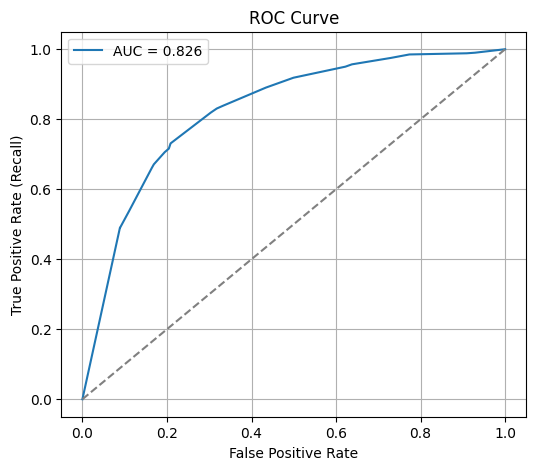

In [11]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc(fpr,tpr):.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Precision–Recall Curve**
</div>

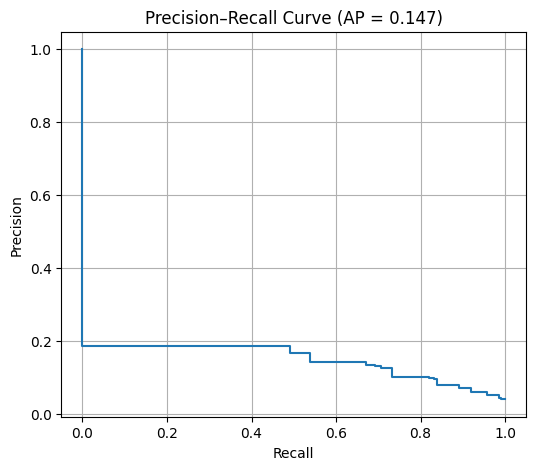

In [12]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve (AP = {ap:.3f})")
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Confusion Matrix**
</div>

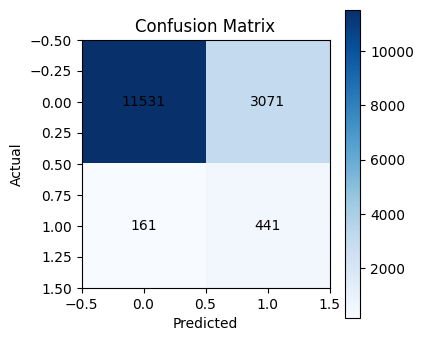

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
for (i,j), val in np.ndenumerate(cm):
    plt.text(j, i, int(val), ha="center", va="center")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Learning Curve — how performance changes with more data**
</div>

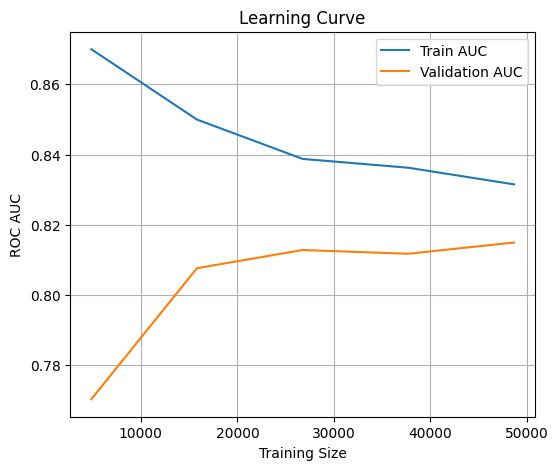

In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5, scoring="roc_auc", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)
plt.figure(figsize=(6,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Train AUC")
plt.plot(train_sizes, np.mean(val_scores, axis=1), label="Validation AUC")
plt.xlabel("Training Size")
plt.ylabel("ROC AUC")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Validation Curve - sensitivity to a single hyperparameter (max_depth)**
</div>

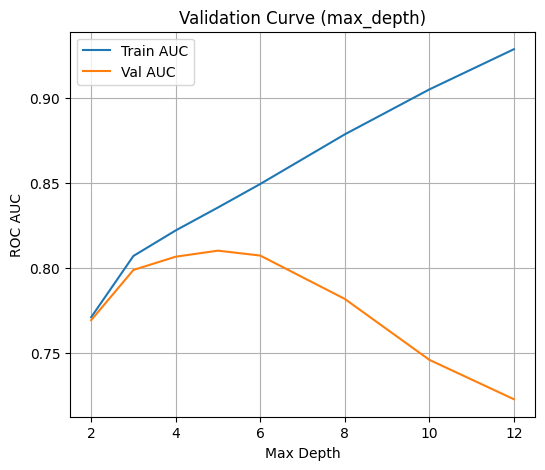

In [15]:
param_range = [2,3,4,5,6,8,10,12]
train_scores, test_scores = validation_curve(
    pipe, X_train, y_train,
    param_name="clf__max_depth",
    param_range=param_range,
    cv=3,
    scoring="roc_auc"
)
plt.figure(figsize=(6,5))
plt.plot(param_range, np.mean(train_scores, axis=1), label="Train AUC")
plt.plot(param_range, np.mean(test_scores, axis=1), label="Val AUC")
plt.xlabel("Max Depth")
plt.ylabel("ROC AUC")
plt.title("Validation Curve (max_depth)")
plt.legend()
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Feature Importances - interpretability**
</div>

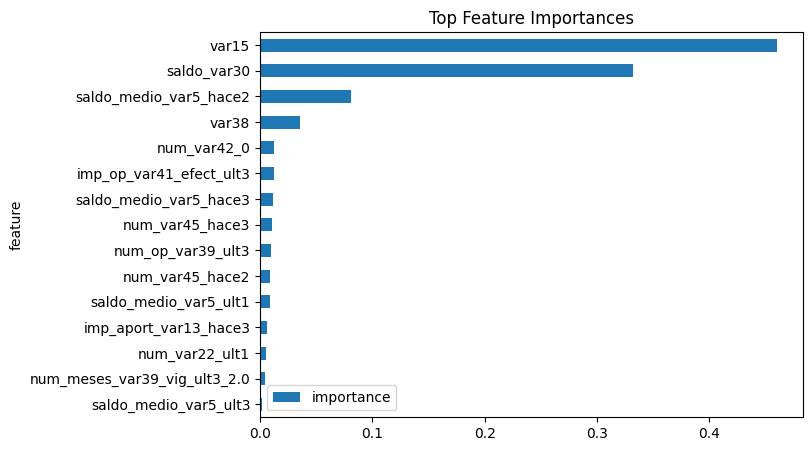

In [16]:
preproc = best_model.named_steps["preproc"]
num_names = numeric_cols
ohe = preproc.named_transformers_["cat"].named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(categorical_cols))
feature_names_all = num_names + cat_names

importances = best_model.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({"feature": feature_names_all, "importance": importances})
feat_imp.sort_values("importance", ascending=False, inplace=True)
feat_imp.head(15).plot.barh(x="feature", y="importance", figsize=(7,5), title="Top Feature Importances")
plt.gca().invert_yaxis()
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Decision Tree Visualization (first few levels)**
</div>

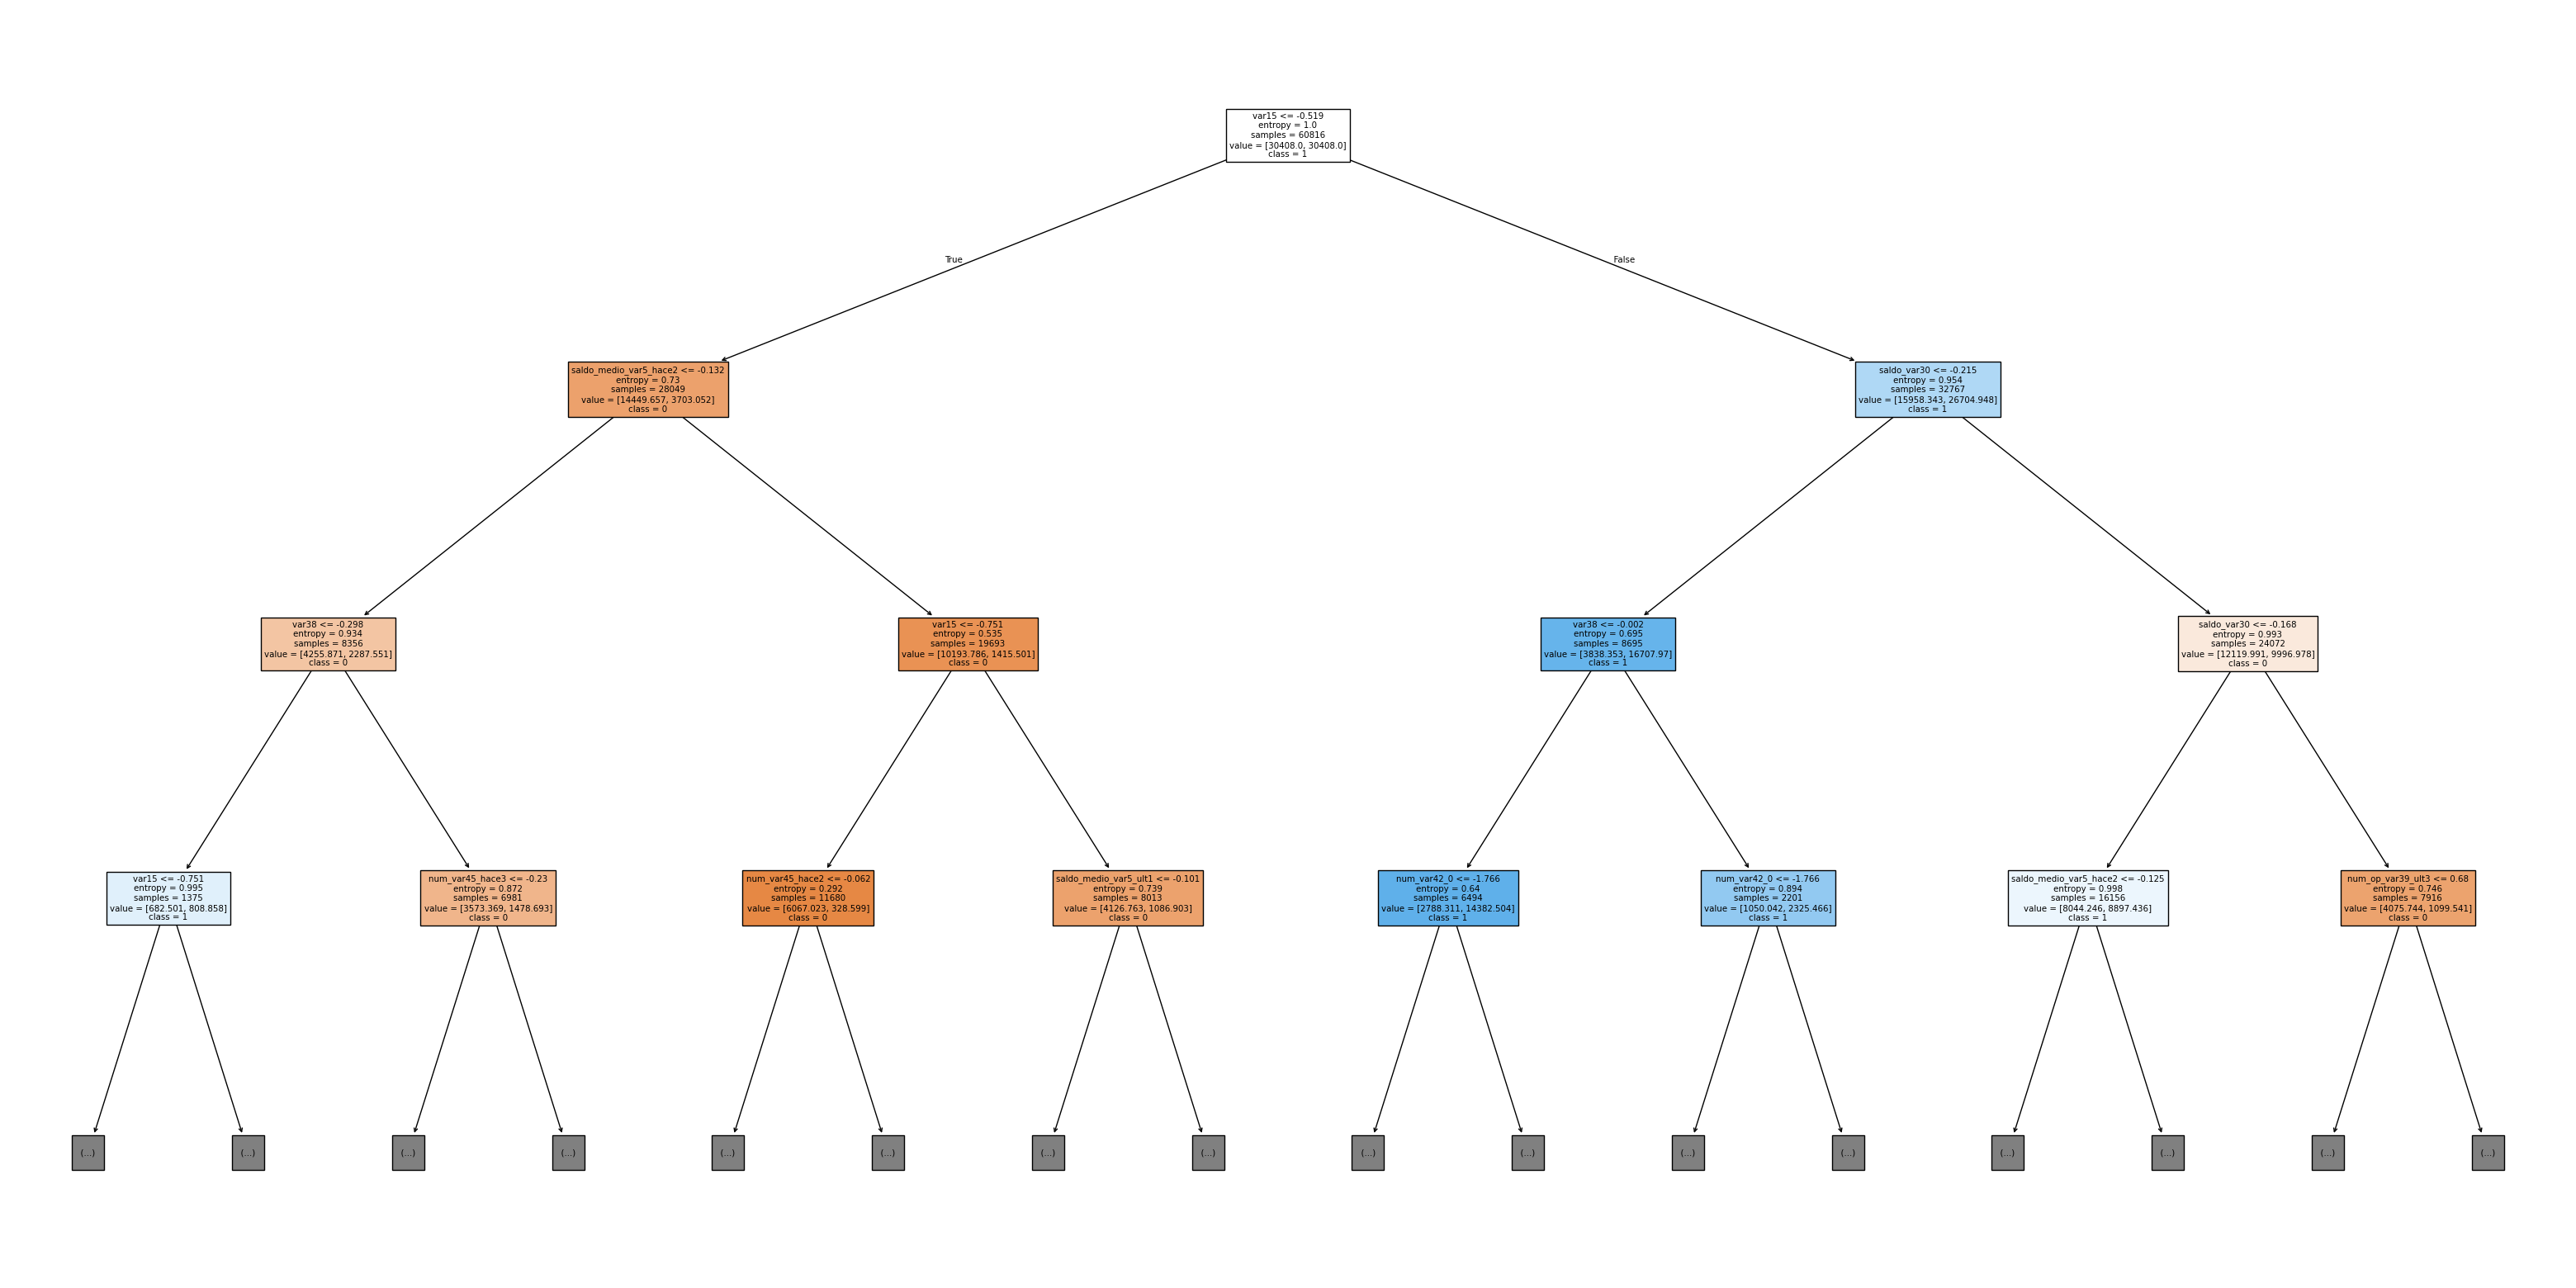

In [19]:
plt.figure(figsize=(40,20))
plot_tree(
    best_model.named_steps["clf"],
    feature_names=feature_names_all,
    class_names=["0","1"],
    max_depth=3, filled=True
)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

**Calibration (Reliability) Plot**
</div>

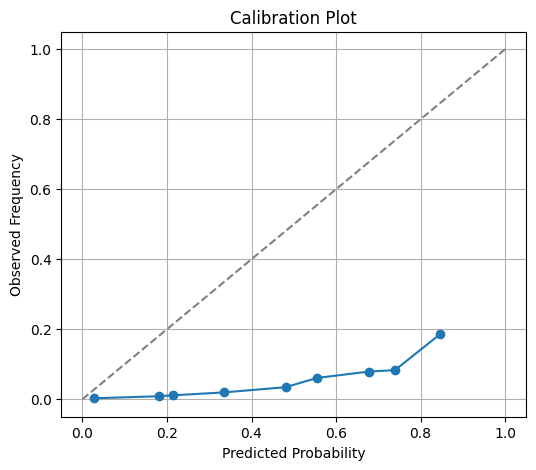

In [20]:
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, "o-")
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Plot")
plt.grid(True)
plt.show()

<div class="alert" style="background-color: #FEF9E7; border-left: 8px solid #D4AC0D; padding: 14px; border-radius: 8px; font-size: 14px; color: #000000;">

### **Make Predictions on Holdout (Test Data)**
Generate predicted labels and probabilities for unseen samples.

</div>

In [21]:
# add ID column back to df_test
test_ids = pd.read_csv(paths.get_interim_data_path("test_ids.csv"))
df_test["ID"] = test_ids["ID"]

# Ensure test dataset contains same columns as train
assert all(col in df_test.columns for col in X_train.columns), \
    "df_test must contain same feature columns as training data."

# --- Predict class probabilities and labels
y_test_pred_proba = best_model.predict_proba(df_test)[:, 1]   # probability of class 1
y_test_pred_label = best_model.predict(df_test)               # 0/1 hard predictions

# --- Attach predictions to original dataframe
df_test_pred = df_test.copy()
df_test_pred["pred_proba"] = y_test_pred_proba
df_test_pred["pred_label"] = y_test_pred_label

# --- Inspect results
print(df_test_pred[["pred_proba", "pred_label"]].head())

# --- Optional: save to file for submission or analysis
# baseline submission file
df_test_pred_labels = df_test_pred[["ID", "pred_label"]]
# rename columns for submission
df_test_pred_labels.columns = ["ID", "TARGET"]
display(df_test_pred_labels)

df_test_pred_labels.to_csv(
    paths.get_subs_path("03_01_baseline_test_predictions.csv")
    , index=False
)
# df_test_pred_labels.to_csv(
#     paths.get_reports_path("03_01_baseline_test_predictions.csv"), index=False
# )


   pred_proba  pred_label
0        0.49           0
1        0.49           0
2        0.00           0
3        0.15           0
4        0.04           0


,ID,TARGET
0,2,0
1,5,0
2,6,0
3,7,0
4,9,0
...,...,...
75813,151831,0
75814,151832,0
75815,151833,0
75816,151834,1
